In [124]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.modeller import *
from sklearn.metrics import r2_score
from src.wiener_filter import *
import copy

import mat73
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA


%load_ext autoreload 
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [125]:
post=100
session_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'

session = MPOptoClass(session_path, post=post)

love


# 0. are there lasers happening when there isn't climbing?

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


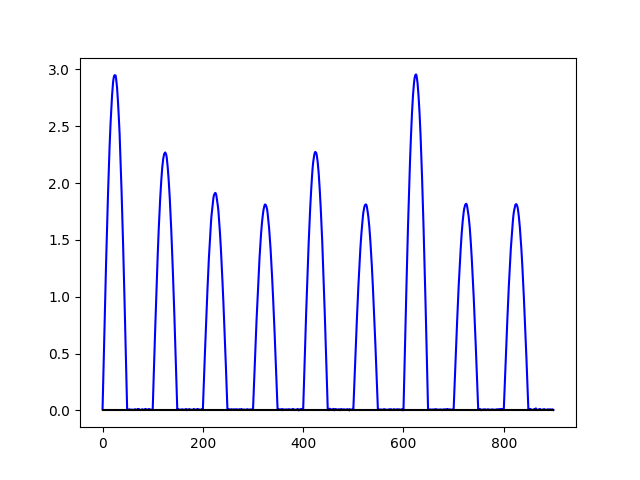

In [126]:
all_laser_bounds, nada = getLaserBounds(session.laser['laser_ts'], post=post)
bads = [np.any(session.climbing_logical[bound[0]:bound[1]]==0) for bound in all_laser_bounds]

bad_lasers_bounds = all_laser_bounds[bads, :]
duration = bad_lasers_bounds[-1,-1]
bad_lasers = arr2trials(session.laser['laser_ts'][:duration], bad_lasers_bounds, duration=duration, concat=True)
bad_climbs = arr2trials(session.climbing_logical[:duration], bad_lasers_bounds, duration=duration, concat=True)


fig0, ax0 = plt.subplots()
ax0.plot(bad_lasers, c='blue')
ax0.plot(bad_climbs, c='black')

# 1. using 10 ms bins, 10 bins of history, how well can we predict PC rates

In [127]:
(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10)

In [128]:
#output_PCA = LR_kfolds(all_nlags_PCA, all_cut_PCA)
#output_PCA = pload('/home/diya/Documents/mp_opto/picklejar/output_PCA_10binsize_10nlags.pickle')

In [129]:
output_PCA = Ridge_kfolds(all_nlags_PCA, all_cut_PCA, alpha=100000)

10it [00:47,  4.70s/it]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0, 0.5, 'r^2')

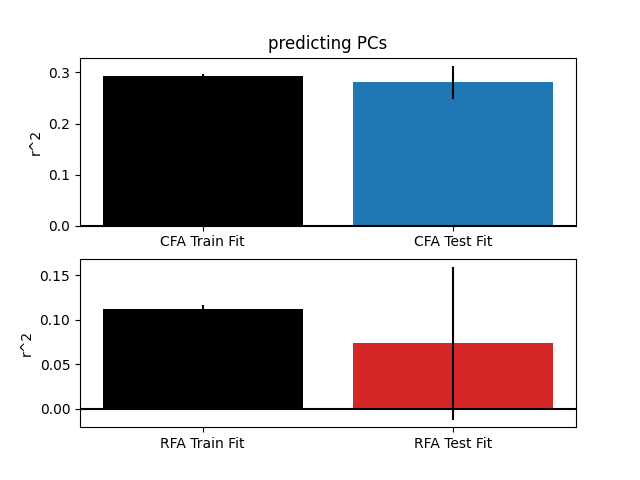

In [130]:
all_train_scores = np.array(output_PCA['fit_scores'])
all_train_var = np.array(output_PCA['fit_variance'])
all_test_scores = np.array(output_PCA['test_scores'])
all_test_var = np.array(output_PCA['test_variance'])

wtrain_CFA = np.average(all_train_scores[:, :session.num_CFA], axis=1, weights=all_train_var[:, :session.num_CFA])
wtrain_RFA = np.average(all_train_scores[:, session.num_CFA:], axis=1, weights=all_train_var[:, session.num_CFA:])
wtest_CFA = np.average(all_test_scores[:, :session.num_CFA], axis=1, weights=all_test_var[:, :session.num_CFA])
wtest_RFA = np.average(all_test_scores[:, session.num_CFA:], axis=1, weights=all_test_var[:, session.num_CFA:])


avg_wtrain_CFA = np.average(wtrain_CFA)
std_wtrain_CFA = np.std(wtrain_CFA)
avg_wtrain_RFA = np.average(wtrain_RFA)
std_wtrain_RFA = np.std(wtrain_RFA)

avg_wtest_CFA = np.average(wtest_CFA)
std_wtest_CFA = np.std(wtest_CFA)
avg_wtest_RFA = np.average(wtest_RFA)
std_wtest_RFA = np.std(wtest_RFA)

train_CFA = all_train_scores[:, :session.num_CFA]
train_RFA = all_train_scores[:, session.num_CFA:]
test_CFA = all_test_scores[:, :session.num_CFA]
test_RFA = all_test_scores[:, session.num_CFA:]

average_train_CFA = np.average(train_CFA, axis=0)
average_train_RFA = np.average(train_RFA, axis=0)
average_test_CFA = np.average(test_CFA, axis=0)
average_test_RFA = np.average(test_RFA, axis=0)


fig10, ax10 = plt.subplots(2, 1)
labels = ['CFA Train Fit', 'CFA Test Fit']
labels_RFA = ['RFA Train Fit', 'RFA Test Fit']
ax10[0].bar(labels, [avg_wtrain_CFA, avg_wtest_CFA], yerr=[std_wtrain_CFA, std_wtest_CFA], color=('black', 'tab:blue'))
ax10[0].axhline(0,  color='black')
ax10[1].bar(labels_RFA, [avg_wtrain_RFA, avg_wtest_RFA], yerr=[std_wtrain_RFA, std_wtest_RFA], color=('black', 'tab:red'))
ax10[1].axhline(0,  color='black')

ax10[0].set_title('predicting PCs')
ax10[0].set_ylabel('r^2')
ax10[1].set_ylabel('r^2')



/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


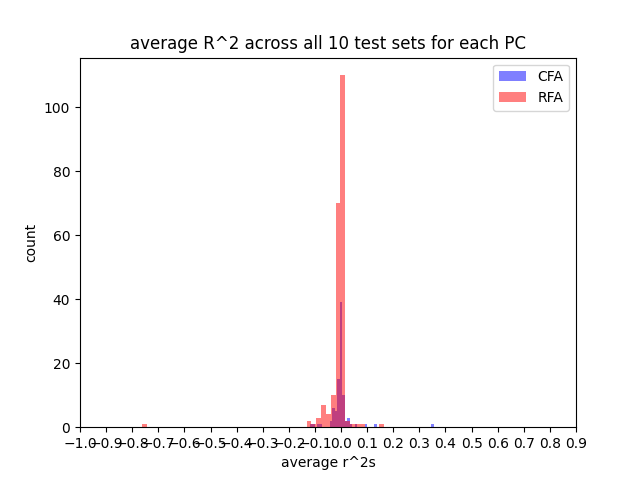

In [131]:
fig1, ax1 = plt.subplots()
ax1.hist(average_test_CFA, bins=50, color='blue', alpha=0.5, label='CFA')
ax1.hist(average_test_RFA, bins=50, color='red', alpha=0.5, label='RFA')
#fig1.suptitle('how well we can predict PCs of CFA or RFA using all PCs and their history')
ax1.set_title('average R^2 across all 10 test sets for each PC')
ax1.set_xlabel('average r^2s')
ax1.set_ylabel('count')
ax1.legend()
ax1.set_xticks(np.arange(-1,1, .1))

# 2. a few amount of PCs, the modelling isn't terrible. 

In [132]:
best_CFA_ind = np.flip(np.unravel_index(np.argsort(test_CFA, axis=None), test_CFA.shape))
best_RFA_ind = np.flip(np.unravel_index(np.argsort(test_RFA, axis=None), test_RFA.shape))
best_RFA_ind[0,:] = best_RFA_ind[0,:] + session.num_CFA

CFA PC:0


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'CFA PC:0,  r^2 = 0.4080768320232778')

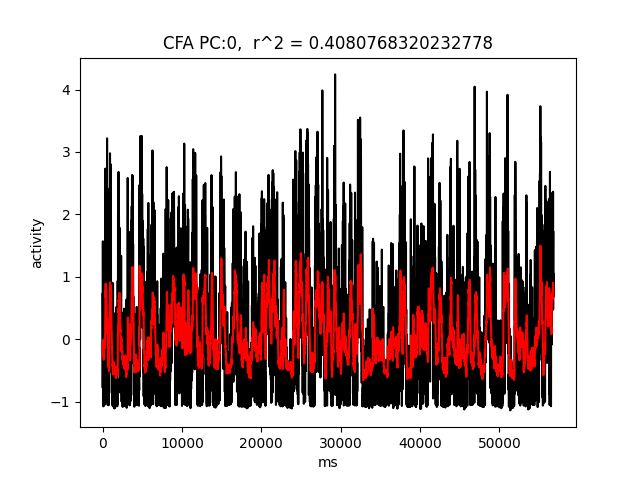

In [133]:
num=0
PC_num = best_CFA_ind[0,num]
print(f'CFA PC:{PC_num}')
fold = best_CFA_ind[1,num]
model = output_PCA['models'][fold]
true = output_PCA['test_sets'][fold][1][:, PC_num]
temp = model.predict(output_PCA['test_sets'][fold][0])
predic = temp[:, PC_num]

fig2, ax2 = plt.subplots()
x = np.arange(true.shape[0])*10
ax2.plot(x, true, c='black', label='true')
ax2.plot(x, predic, c='red', label='predicted')
ax2.set_xlabel('ms')
ax2.set_ylabel('activity')
r2 = r2_score(true, predic)
ax2.set_title(f'CFA PC:{PC_num},  r^2 = {r2}')

RFA PC1


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


ValueError: x and y must have same first dimension, but have shapes (5682,) and (5683,)

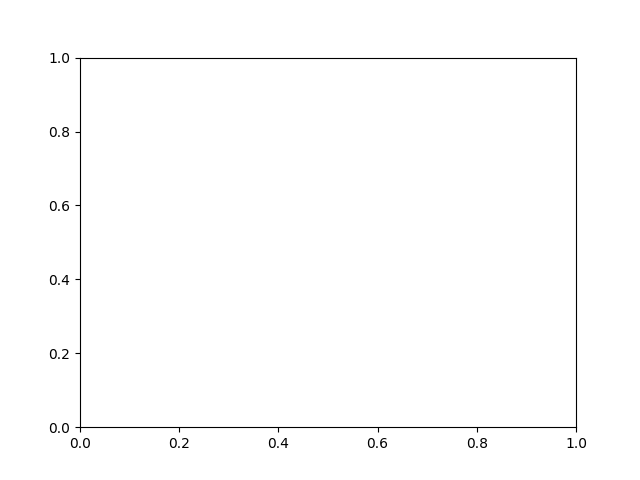

In [135]:
num=1
PC_num = best_RFA_ind[0,num]
print(f'RFA PC{PC_num - session.num_CFA}')
fold = best_RFA_ind[1,num]
model = output_PCA['models'][fold]
true = output_PCA['test_sets'][fold][0][:, PC_num]
temp = model.predict(output_PCA['test_sets'][fold][0])
predic = temp[:,PC_num]

fig20, ax20 = plt.subplots()
ax20.plot(x, true, c='black')
ax20.plot(x, predic, c='red')
r2 = r2_score(true, predic)
ax20.set_title(f'RFA PC: {PC_num - session.num_CFA}, r^2 = {r2}')

# 3. okay, now lets train on ALL climbing data EXCEPT CTRL data and LASER data

In [136]:
pre = 100
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)

In [137]:
(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)

In [138]:
reg = Ridge(alpha=10000)
#reg = LinearRegression()
reg.fit(all_nlags_PCA, all_cut_PCA)
predic = reg.predict(all_nlags_PCA)
all_climbing = r2_score(all_cut_PCA, predic, multioutput='raw_values')

In [139]:
CFA_lt, RFA_lt = session.binner(bounds=psth_bounds, fs=10, concat=True)
CFA_lt_PCA = CFA_PCObj.transform(CFA_lt)
#CFA_lt_PCA = unstitchSeams(CFA_lt_PCA, getSeamsFromBounds(omitLaserBounds, binsize=10))


RFA_lt_PCA = RFA_PCObj.transform(RFA_lt)
#RFA_lt_PCA = unstitchSeams(RFA_lt_PCA, getSeamsFromBounds(omitLaserBounds, binsize=10))

all_lt_PCA = np.hstack((CFA_lt_PCA, RFA_lt_PCA))
all_lt_PCA = unstitchSeams(all_lt_PCA, getSeamsFromBounds(bounds=psth_bounds, binsize=10))

In [140]:
all_laser_input, all_laser_true = format_and_stitch(all_lt_PCA, all_lt_PCA)

all_laser_input = all_laser_input[:-1, :]
all_laser_true = all_laser_true[1:,:]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'RFA PC: 1, r^2: 0.23208054091807895')

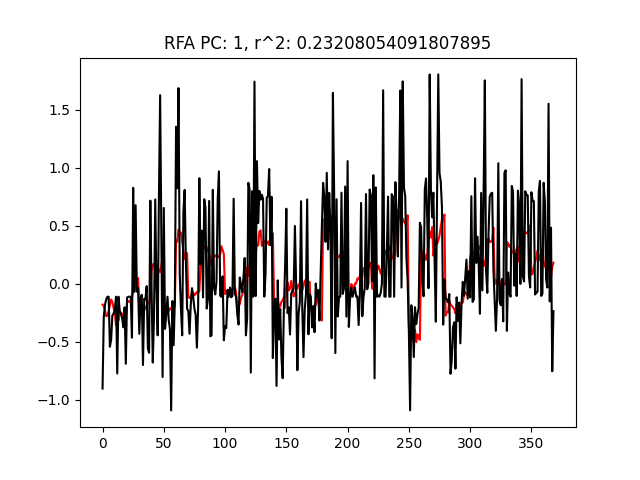

In [141]:
num=0
PC_num = best_RFA_ind[0,num]

all_laser_predic = reg.predict(all_laser_input)
all_laser_predic_var = np.var(all_laser_predic, axis=0)
laser_scores = r2_score(all_laser_true, all_laser_predic, multioutput = 'raw_values')
fig3, ax3 = plt.subplots()
score = r2_score(all_laser_true[:,PC_num], all_laser_predic[:,PC_num])
ax3.plot(all_laser_predic[:,PC_num], c='red')
ax3.plot(all_laser_true[:,PC_num], c='black')
ax3.set_title(f'RFA PC: {PC_num - session.num_CFA}, r^2: {score}')


In [142]:
CFA_clt, RFA_clt = session.binner(bounds=psth_ctrl_bounds, fs=10, concat=True)
CFA_clt_PCA = CFA_PCObj.transform(CFA_clt)
#CFA_lt_PCA = unstitchSeams(CFA_lt_PCA, getSeamsFromBounds(omitLaserBounds, binsize=10))

RFA_clt_PCA = RFA_PCObj.transform(RFA_clt)
#RFA_lt_PCA = unstitchSeams(RFA_lt_PCA, getSeamsFromBounds(omitLaserBounds, binsize=10))

all_clt_PCA = np.hstack((CFA_clt_PCA, RFA_clt_PCA))
all_clt_PCA = unstitchSeams(all_clt_PCA, getSeamsFromBounds(bounds=psth_ctrl_bounds, binsize=10))

In [143]:
all_c_laser_input, all_c_laser_true = format_and_stitch(all_clt_PCA, all_clt_PCA)

all_c_laser_input = all_c_laser_input[:-1, :]
all_c_laser_true = all_c_laser_true[1:,:]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'CTRL, RFA PC: 1, r^2: 0.16020974791649711')

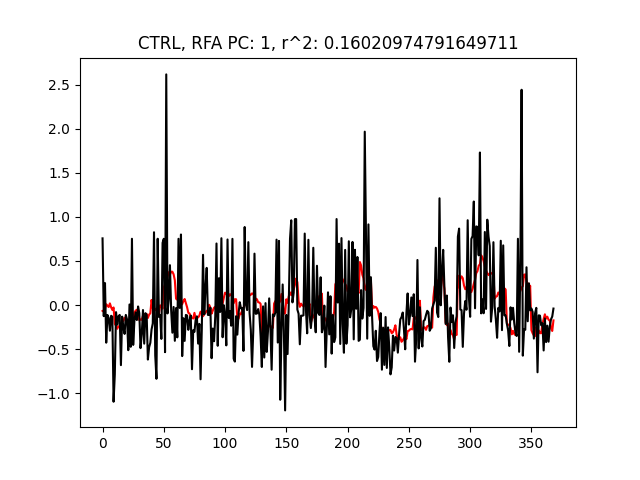

In [144]:
num=0
PC_num = best_RFA_ind[0,num]

all_c_laser_predic = reg.predict(all_c_laser_input)
all_c_laser_predic_var = np.var(all_c_laser_predic, axis=0)


laser_c_scores = r2_score(all_c_laser_true, all_c_laser_predic, multioutput = 'raw_values')
fig32, ax32 = plt.subplots()
score = r2_score(all_c_laser_true[:,PC_num], all_c_laser_predic[:,PC_num])
ax32.plot(all_c_laser_predic[:,PC_num], c='red')
ax32.plot(all_c_laser_true[:,PC_num], c='black')
ax32.set_title(f'CTRL, RFA PC: {PC_num - session.num_CFA}, r^2: {score}')


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0, 0.5, 'r^2')

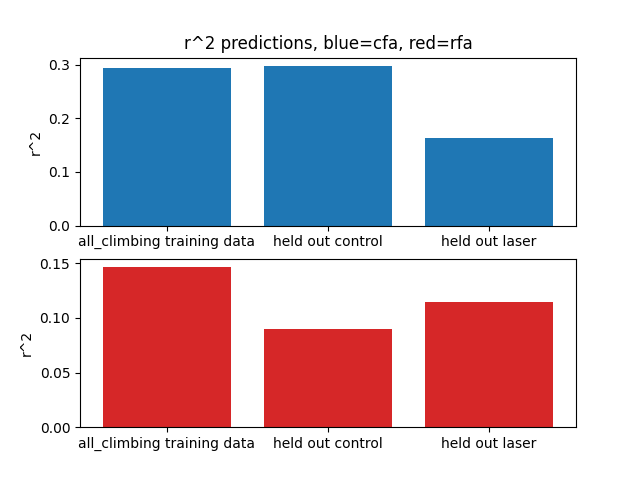

In [145]:
climbing_RFA = all_climbing[session.num_CFA:]
climbing_RFA_var = np.var(predic[:, session.num_CFA:], axis=0)
climbing_CFA = all_climbing[:session.num_CFA]
climbing_CFA_var = np.var(predic[:, :session.num_CFA], axis=0)

laser_cfa_scores = laser_scores[:session.num_CFA]
laser_rfa_scores = laser_scores[session.num_CFA:]
laser_ccfa_scores = laser_c_scores[:session.num_CFA]
laser_crfa_scores = laser_c_scores[session.num_CFA:]

weighted_climbing_CFA_scores = np.average(climbing_CFA, weights = climbing_CFA_var)
weighted_climbing_RFA_scores = np.average(climbing_RFA, weights = climbing_RFA_var)

weighted_cfa_scores = np.average(laser_cfa_scores, weights = all_laser_predic_var[:session.num_CFA]) 
weighted_rfa_scores = np.average(laser_rfa_scores, weights = all_laser_predic_var[session.num_CFA:]) 

weighted_ccfa_scores = np.average(laser_ccfa_scores, weights = all_c_laser_predic_var[:session.num_CFA]) 
weighted_crfa_scores = np.average(laser_crfa_scores, weights = all_c_laser_predic_var[session.num_CFA:]) 

fig34,ax34 = plt.subplots(nrows=2, ncols=1)
labels = ['all_climbing training data', 'held out control', 'held out laser']
bars = [weighted_climbing_CFA_scores, weighted_ccfa_scores, weighted_cfa_scores]
ax34[0].bar(labels, bars, color='tab:blue')

bars = [weighted_climbing_RFA_scores, weighted_crfa_scores, weighted_rfa_scores]
ax34[1].bar(labels, bars, color='tab:red')

ax34[0].set_title('r^2 predictions, blue=cfa, red=rfa')
ax34[0].set_ylabel('r^2')
ax34[1].set_ylabel('r^2')

